Аналитика отмен бронирований в отеле

Описание проекта
Цель проекта — разработка системы анализа и прогнозирования отмен бронирований на основе обезличенных данных.

Проект имитирует реальный аналитический инструмент, используемый в гостиничном бизнесе для:
- снижения уровня отмен
- увеличения дохода
- оптимизации каналов продаж

Важно
В проекте используются синтетические данные, повторяющие структуру реальных,
но не содержащие конфиденциальной информации.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [20]:
from sklearn.model_selection import train_test_split

1. Генерация данных

In [21]:
N = 5000

data = pd.DataFrame({
    "booking_advance_level": np.random.choice(
        ["last_minute", "standard", "early"], N, p=[0.3, 0.5, 0.2]
    ),
    "price_segment": np.random.choice(
        ["low", "mid", "high"], N, p=[0.4, 0.4, 0.2]
    ),
    "room_type": np.random.choice(
        ["standard", "comfort", "lux"], N, p=[0.5, 0.3, 0.2]
    ),
    "channel": np.random.choice(
        ["direct_web", "OTA", "phone"], N, p=[0.4, 0.45, 0.15]
    ),
    "refund_policy": np.random.choice(
        ["non_refundable", "semi_flexible", "flexible"], N, p=[0.5, 0.3, 0.2]
    ),
})

In [22]:
risk = (
    0.15
    + 0.25 * (data["booking_advance_level"] == "early")
    + 0.20 * (data["channel"] == "OTA")
    + 0.20 * (data["refund_policy"] == "flexible")
)

data["cancel_probability"] = np.clip(risk, 0, 0.95)

data["is_cancelled"] = (
    np.random.rand(N) < data["cancel_probability"]
).astype(int)

2. Анализ отмен

In [23]:
print(f"Общий уровень отмен: {data['is_cancelled'].mean():.2%}")

Общий уровень отмен: 32.82%


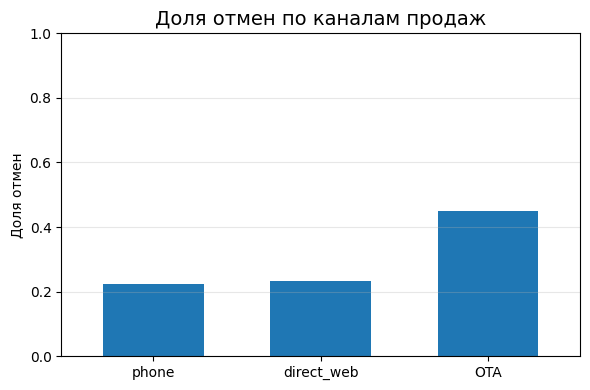

In [24]:
# ГРАФИК 1 — каналы
plot1 = data.groupby("channel")["is_cancelled"].mean().sort_values()

plt.figure(figsize=(6,4))
plot1.plot(kind="bar", width=0.6)

plt.title("Доля отмен по каналам продаж", fontsize=14)
plt.ylabel("Доля отмен")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, 1)
plt.show()

3. Модель прогнозирования

In [25]:
data_encoded = pd.get_dummies(data, drop_first=True)

X = data_encoded.drop(["is_cancelled", "cancel_probability"], axis=1)
y = data_encoded["is_cancelled"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.88      0.80       679
           1       0.57      0.32      0.41       321

    accuracy                           0.70      1000
   macro avg       0.65      0.60      0.61      1000
weighted avg       0.68      0.70      0.68      1000



4. Финансовый эффект

In [26]:
avg_price = {
    "low": 4000,
    "mid": 8000,
    "high": 12000
}

data["estimated_price"] = data["price_segment"].map(avg_price)

lost_revenue = data[data["is_cancelled"] == 1]["estimated_price"].sum()

print(f"Потери от отмен: {lost_revenue:,.0f} руб.")

Потери от отмен: 11,776,000 руб.


In [27]:
print("\nРЕКОМЕНДАЦИИ:\n")

if data.groupby("channel")["is_cancelled"].mean()["OTA"] > 0.4:
    print("- Снизить зависимость от OTA")

if data.groupby("refund_policy")["is_cancelled"].mean()["flexible"] > 0.4:
    print("- Ограничить гибкие тарифы")


РЕКОМЕНДАЦИИ:

- Снизить зависимость от OTA
- Ограничить гибкие тарифы


5. Итоговый дашборд

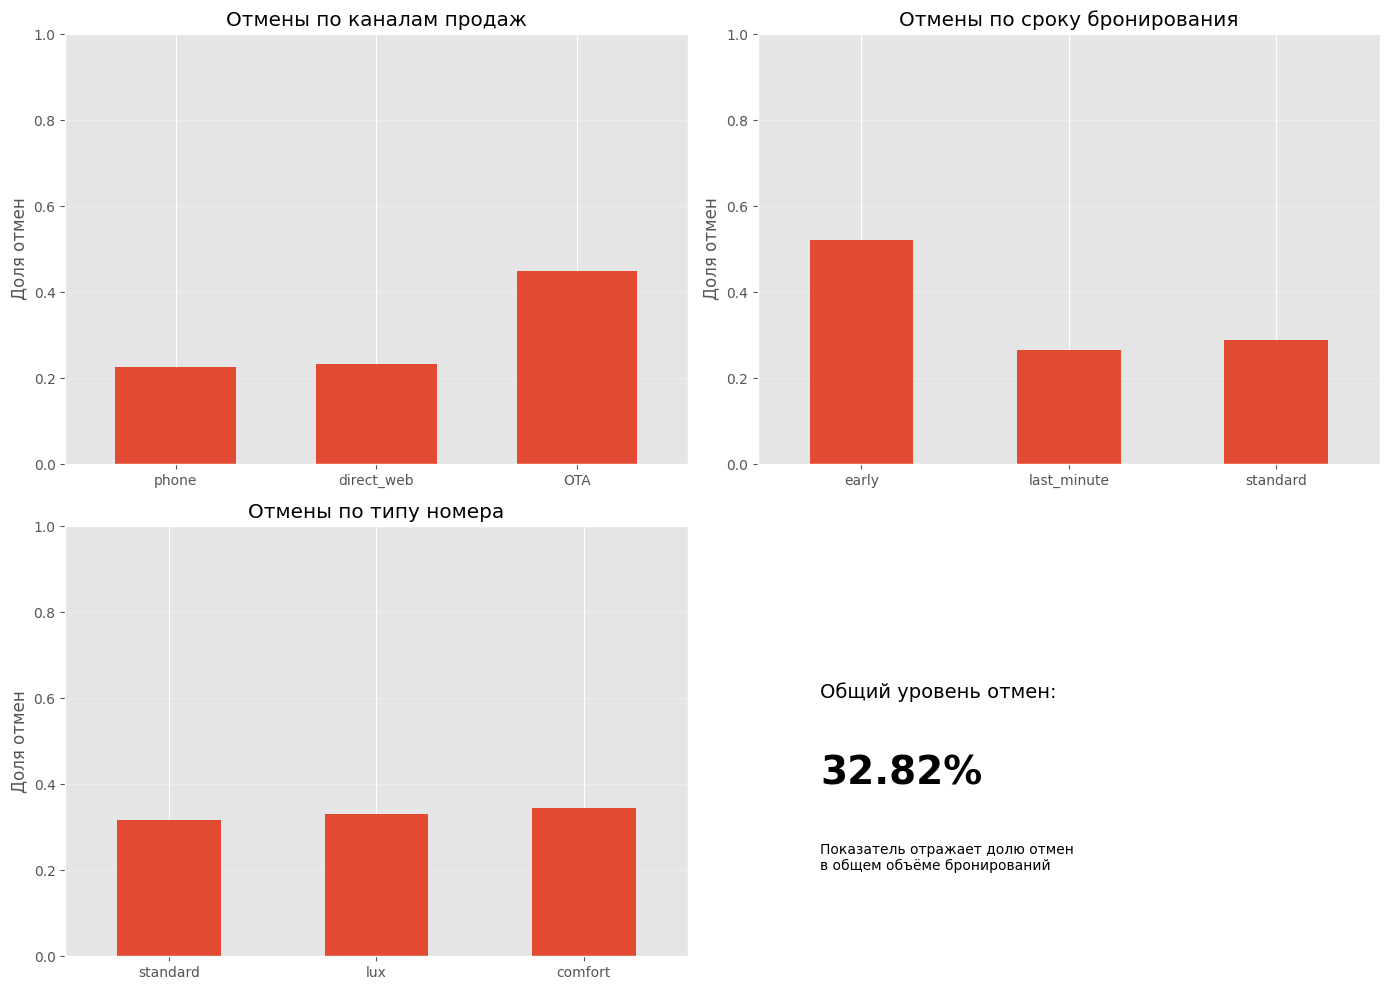

In [29]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

fig = plt.figure(figsize=(14,10))

# -----------------------
# 1. Каналы продаж
# -----------------------
ax1 = plt.subplot(2,2,1)

plot1 = data.groupby("channel")["is_cancelled"].mean().sort_values()
plot1.plot(kind="bar", width=0.6, ax=ax1)

ax1.set_title("Отмены по каналам продаж")
ax1.set_ylabel("Доля отмен")
ax1.set_xlabel("")
ax1.set_ylim(0,1)
ax1.tick_params(axis='x', rotation=0)
ax1.grid(axis="y", alpha=0.3)


# -----------------------
# 2. Срок бронирования
# -----------------------
ax2 = plt.subplot(2,2,2)

plot2 = data.groupby("booking_advance_level")["is_cancelled"].mean()
plot2.plot(kind="bar", ax=ax2)

ax2.set_title("Отмены по сроку бронирования")
ax2.set_ylabel("Доля отмен")
ax2.set_xlabel("")
ax2.set_ylim(0,1)
ax2.tick_params(axis='x', rotation=0)
ax2.grid(axis="y", alpha=0.3)


# -----------------------
# 3. Тип номера
# -----------------------
ax3 = plt.subplot(2,2,3)

plot3 = data.groupby("room_type")["is_cancelled"].mean().sort_values()
plot3.plot(kind="bar", ax=ax3)

ax3.set_title("Отмены по типу номера")
ax3.set_ylabel("Доля отмен")
ax3.set_xlabel("")
ax3.set_ylim(0,1)
ax3.tick_params(axis='x', rotation=0)
ax3.grid(axis="y", alpha=0.3)


# -----------------------
# 4. Общий KPI
# -----------------------
ax4 = plt.subplot(2,2,4)
ax4.axis("off")

cancellation_rate = data["is_cancelled"].mean()

ax4.text(0.1, 0.6, "Общий уровень отмен:", fontsize=14)
ax4.text(0.1, 0.4, f"{cancellation_rate:.2%}", fontsize=28, fontweight="bold")

ax4.text(0.1, 0.2, "Показатель отражает долю отмен\nв общем объёме бронирований", fontsize=10)


plt.tight_layout()
plt.show()